In [1]:
import os
import pandas as pd
from glob import glob

folder_path = r"C:\Users\exm499\Downloads\PFAS_classification"
file_list = glob(os.path.join(folder_path, "*.xlsx"))

all_assay_names = set()
pfas_assay_data = {}

# Step 1: 중복 제거 및 정제된 assay 목록 구성
for file in file_list:
    pfas_name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_excel(file)

    if {"NAME", "HIT_CALL"}.issubset(df.columns):
        df = df[["NAME", "HIT_CALL"]].copy()
        df["HIT_CALL"] = df["HIT_CALL"].fillna("NA")

        # 중복 제거 로직 적용
        cleaned = []
        for assay_name, group in df.groupby("NAME"):
            calls = group["HIT_CALL"].tolist()
            if "Active" in calls:
                cleaned.append((assay_name, "Active"))
            elif all(call == "Inactive" for call in calls):
                cleaned.append((assay_name, "Inactive"))
            else:
                cleaned.append((assay_name, "NA"))

        # 정제된 데이터 저장
        assay_dict = dict(cleaned)
        pfas_assay_data[pfas_name] = assay_dict
        all_assay_names.update(assay_dict.keys())

# Step 2: 전체 assay 기준 매트릭스 생성
sorted_assays = sorted(all_assay_names)
matrix = []

for pfas in sorted(pfas_assay_data.keys()):
    row = []
    assay_data = pfas_assay_data[pfas]
    for assay in sorted_assays:
        row.append(assay_data.get(assay, "NA"))
    matrix.append(row)

hitcall_df = pd.DataFrame(matrix, index=sorted(pfas_assay_data.keys()), columns=sorted_assays)

# 결과 출력
print(f"✅ 최종 행렬 크기: {hitcall_df.shape} (PFAS × Assay)")
print(hitcall_df.head())

✅ 최종 행렬 크기: (14, 831) (PFAS × Assay)
                                                   ACEA_AR_agonist_80hr  \
1-(Perfluorofluorooctyl)propane-2,3-diol Toxcas...                   NA   
1H,1H,10H,10H-Perfluorodecane-1,10-diol Toxcast...                   NA   
1H,1H,11H,11H-Perfluorotetraethylene glycol Tox...                   NA   
1H,1H,5H,5H-Perfluoro-1,5-pentanediol diacrylat...                   NA   
1H,1H,6H,6H-Perfluorohexane-1,6-diol diacrylate...                   NA   

                                                   ACEA_AR_agonist_AUC_viability  \
1-(Perfluorofluorooctyl)propane-2,3-diol Toxcas...                            NA   
1H,1H,10H,10H-Perfluorodecane-1,10-diol Toxcast...                            NA   
1H,1H,11H,11H-Perfluorotetraethylene glycol Tox...                            NA   
1H,1H,5H,5H-Perfluoro-1,5-pentanediol diacrylat...                            NA   
1H,1H,6H,6H-Perfluorohexane-1,6-diol diacrylate...                            NA   

       

In [2]:
# Optional: Save
output_path = os.path.join(folder_path, "PFAS_HitCall_Matrix_Corrected.xlsx")
hitcall_df.to_excel(output_path)
# print(f"✅ Saved matrix to: {output_path}")

C:\Users\exm499\AppData\Local\Temp\ipykernel_7536\127522864.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


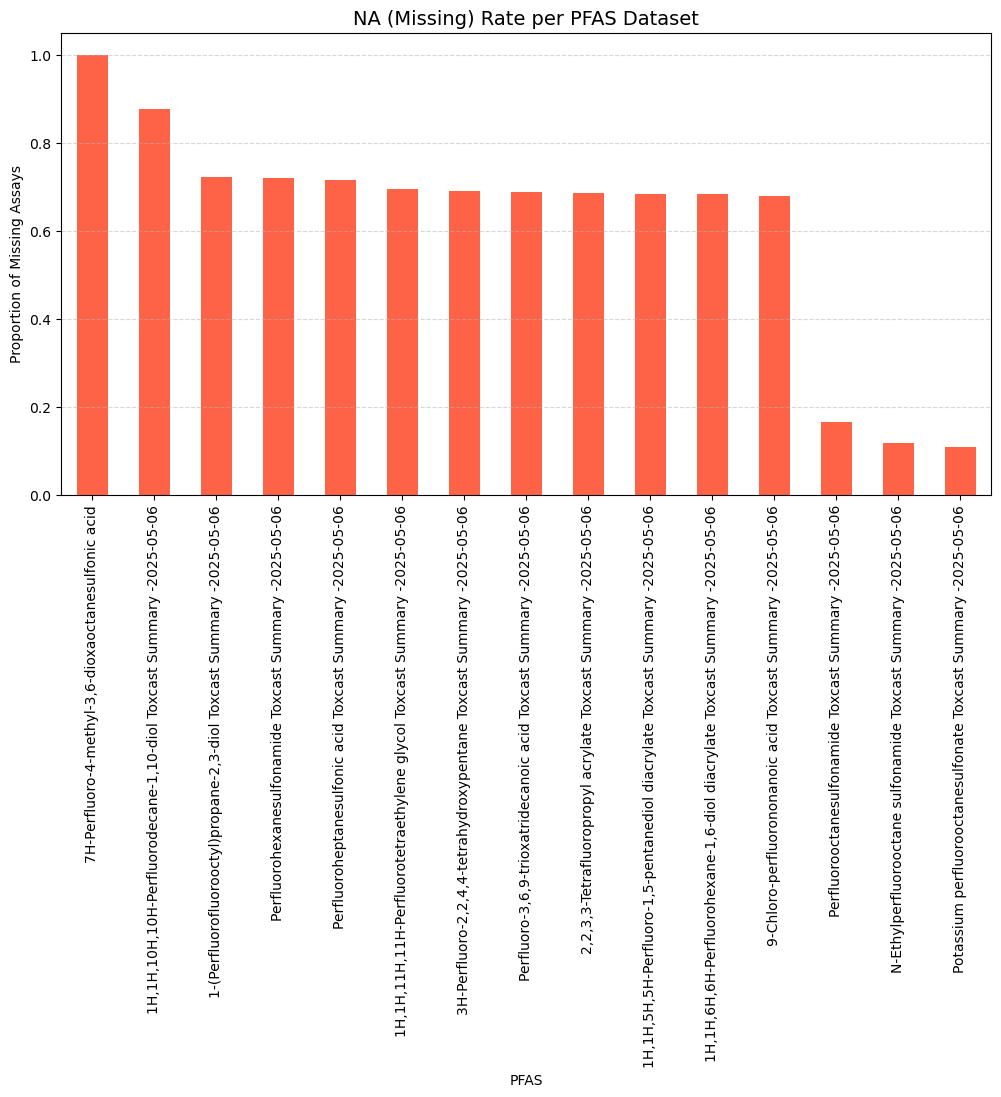

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"C:\Users\exm499\Downloads\PFAS_classification\PFAS_HitCall_Matrix_Corrected.xlsx"
df = pd.read_excel(file_path, index_col=0)

# 'NA' 문자열인지 NaN인지 자동 감지
if (df == 'NA').sum().sum() > 0:
    na_rate = (df == 'NA').sum(axis=1) / df.shape[1]
else:
    na_rate = df.isna().sum(axis=1) / df.shape[1]

# 시각화
plt.figure(figsize=(12, 6))
na_rate.sort_values(ascending=False).plot(kind='bar', color='tomato')
plt.title('NA (Missing) Rate per PFAS Dataset', fontsize=14)
plt.ylabel('Proportion of Missing Assays')
plt.xlabel('PFAS')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

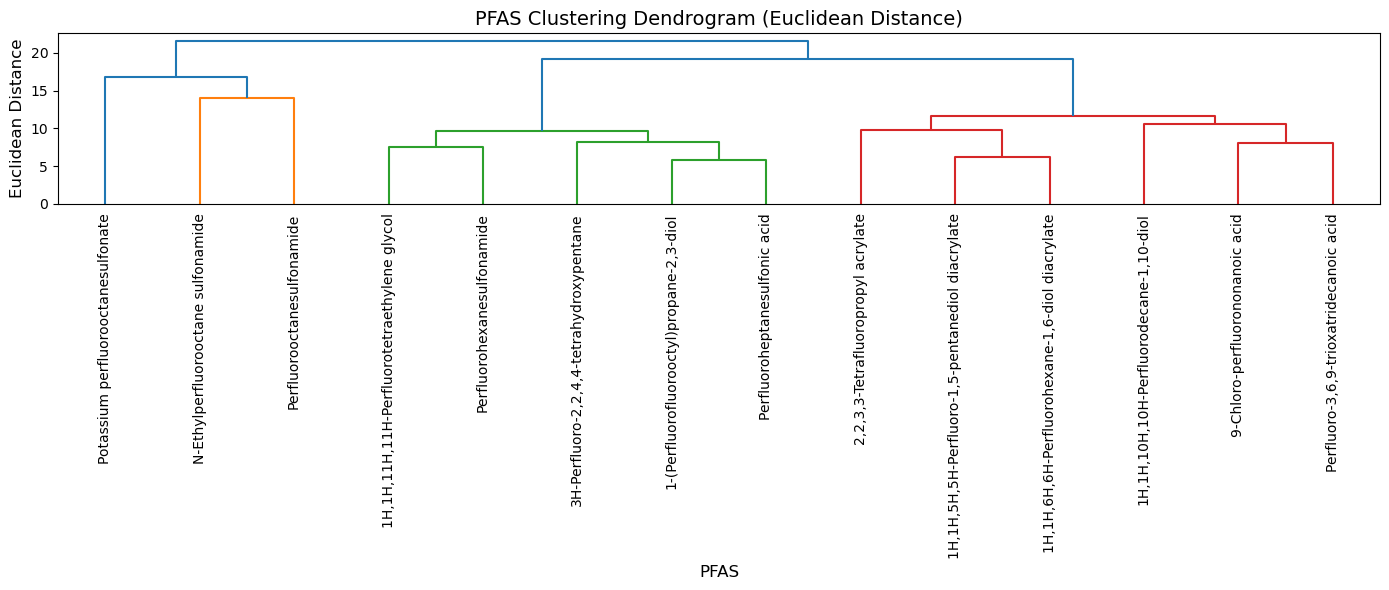

=== 📄 PFAS 이름 매핑 ===
1-(Perfluorofluorooctyl)propane-2,3-diol: 1-(Perfluorofluorooctyl)propane-2,3-diol Toxcast Summary -2025-05-06
1H,1H,10H,10H-Perfluorodecane-1,10-diol: 1H,1H,10H,10H-Perfluorodecane-1,10-diol Toxcast Summary -2025-05-06
1H,1H,11H,11H-Perfluorotetraethylene glycol: 1H,1H,11H,11H-Perfluorotetraethylene glycol Toxcast Summary -2025-05-06
1H,1H,5H,5H-Perfluoro-1,5-pentanediol diacrylate: 1H,1H,5H,5H-Perfluoro-1,5-pentanediol diacrylate Toxcast Summary -2025-05-06
1H,1H,6H,6H-Perfluorohexane-1,6-diol diacrylate: 1H,1H,6H,6H-Perfluorohexane-1,6-diol diacrylate Toxcast Summary -2025-05-06
2,2,3,3-Tetrafluoropropyl acrylate: 2,2,3,3-Tetrafluoropropyl acrylate Toxcast Summary -2025-05-06
3H-Perfluoro-2,2,4,4-tetrahydroxypentane: 3H-Perfluoro-2,2,4,4-tetrahydroxypentane Toxcast Summary -2025-05-06
9-Chloro-perfluorononanoic acid: 9-Chloro-perfluorononanoic acid Toxcast Summary -2025-05-06
N-Ethylperfluorooctane sulfonamide: N-Ethylperfluorooctane sulfonamide Toxcast Summary 

In [3]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import re

# 1. 엑셀 파일 불러오기
file_path = r"C:\Users\exm499\Downloads\PFAS_classification\PFAS_HitCall_Matrix_Corrected.xlsx"
hitcall_df = pd.read_excel(file_path, index_col=0)

# 2. 문자열 값을 숫자로 변환
binary_df = hitcall_df.replace({"Active": 1, "Inactive": 0, "NA": 0}).astype(float)
binary_df = binary_df.fillna(0)

# 3. 전부 0인 열/행 제거
binary_df = binary_df.loc[:, (binary_df != 0).any(axis=0)]
binary_df = binary_df.loc[(binary_df != 0).any(axis=1), :]

# 4. PFAS 이름 축약 함수 (Summary 앞 단어만 + "Toxcast" 제거)
def clean_pfas_name(raw_name):
    name = re.split(r'\s+Summary', raw_name, flags=re.IGNORECASE)[0]
    name = re.sub(r'\bToxcast\b', '', name, flags=re.IGNORECASE)  # "Toxcast" 제거
    return name.strip()

# 5. index 이름 변경
short_index = {old: clean_pfas_name(old) for old in binary_df.index}
binary_df = binary_df.rename(index=short_index)

# 6. 거리 계산 및 linkage
distance_matrix = pdist(binary_df, metric='euclidean')
linked = linkage(distance_matrix, method='ward')

# 7. 덴드로그램 시각화
plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    labels=binary_df.index,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('PFAS Clustering Dendrogram (Euclidean Distance)', fontsize=14)
plt.xlabel('PFAS', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)
plt.tight_layout()
plt.show()

# 8. (선택) 이름 매핑 확인
print("=== 📄 PFAS 이름 매핑 ===")
for original, cleaned in short_index.items():
    print(f"{cleaned}: {original}")

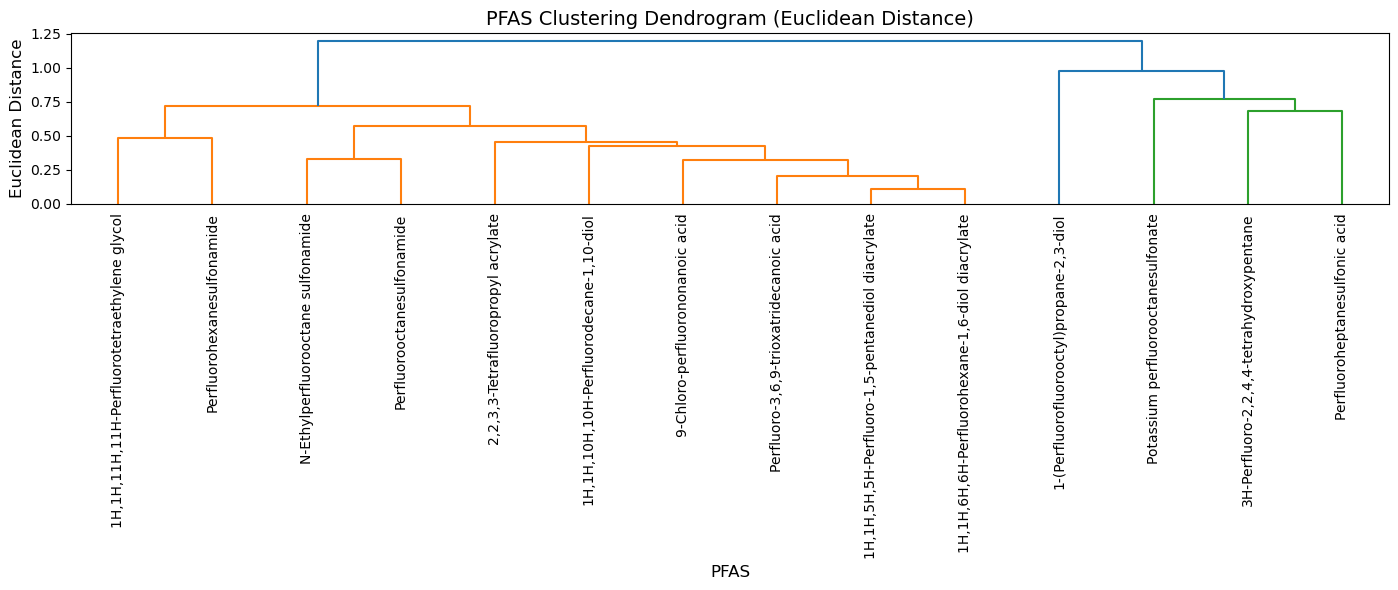

=== 📄 PFAS 이름 매핑 ===
1-(Perfluorofluorooctyl)propane-2,3-diol: 1-(Perfluorofluorooctyl)propane-2,3-diol Toxcast Summary -2025-05-06
1H,1H,10H,10H-Perfluorodecane-1,10-diol: 1H,1H,10H,10H-Perfluorodecane-1,10-diol Toxcast Summary -2025-05-06
1H,1H,11H,11H-Perfluorotetraethylene glycol: 1H,1H,11H,11H-Perfluorotetraethylene glycol Toxcast Summary -2025-05-06
1H,1H,5H,5H-Perfluoro-1,5-pentanediol diacrylate: 1H,1H,5H,5H-Perfluoro-1,5-pentanediol diacrylate Toxcast Summary -2025-05-06
1H,1H,6H,6H-Perfluorohexane-1,6-diol diacrylate: 1H,1H,6H,6H-Perfluorohexane-1,6-diol diacrylate Toxcast Summary -2025-05-06
2,2,3,3-Tetrafluoropropyl acrylate: 2,2,3,3-Tetrafluoropropyl acrylate Toxcast Summary -2025-05-06
3H-Perfluoro-2,2,4,4-tetrahydroxypentane: 3H-Perfluoro-2,2,4,4-tetrahydroxypentane Toxcast Summary -2025-05-06
9-Chloro-perfluorononanoic acid: 9-Chloro-perfluorononanoic acid Toxcast Summary -2025-05-06
N-Ethylperfluorooctane sulfonamide: N-Ethylperfluorooctane sulfonamide Toxcast Summary 

In [4]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import re

# 1. 엑셀 파일 불러오기
file_path = r"C:\Users\exm499\Downloads\PFAS_classification\PFAS_HitCall_Matrix_Corrected.xlsx"
hitcall_df = pd.read_excel(file_path, index_col=0)

# 2. 문자열 값을 숫자로 변환
binary_df = hitcall_df.replace({"Active": 1, "Inactive": 0, "NA": 0}).astype(float)
binary_df = binary_df.fillna(0)

# 3. 전부 0인 열/행 제거
binary_df = binary_df.loc[:, (binary_df != 0).any(axis=0)]
binary_df = binary_df.loc[(binary_df != 0).any(axis=1), :]

# 4. PFAS 이름 축약 함수 (Summary 앞 단어만 + "Toxcast" 제거)
def clean_pfas_name(raw_name):
    name = re.split(r'\s+Summary', raw_name, flags=re.IGNORECASE)[0]
    name = re.sub(r'\bToxcast\b', '', name, flags=re.IGNORECASE)  # "Toxcast" 제거
    return name.strip()

# 5. index 이름 변경
short_index = {old: clean_pfas_name(old) for old in binary_df.index}
binary_df = binary_df.rename(index=short_index)

# 6. 거리 계산 및 linkage
distance_matrix = pdist(binary_df, metric='cosine')
linked = linkage(distance_matrix, method='ward')

# 7. 덴드로그램 시각화
plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    labels=binary_df.index,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('PFAS Clustering Dendrogram (Euclidean Distance)', fontsize=14)
plt.xlabel('PFAS', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)
plt.tight_layout()
plt.show()

# 8. (선택) 이름 매핑 확인
print("=== 📄 PFAS 이름 매핑 ===")
for original, cleaned in short_index.items():
    print(f"{cleaned}: {original}")

✅ 사용할 수 있는 완전한 assay 수: 95개


C:\Users\exm499\AppData\Local\Temp\ipykernel_7536\1951946120.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


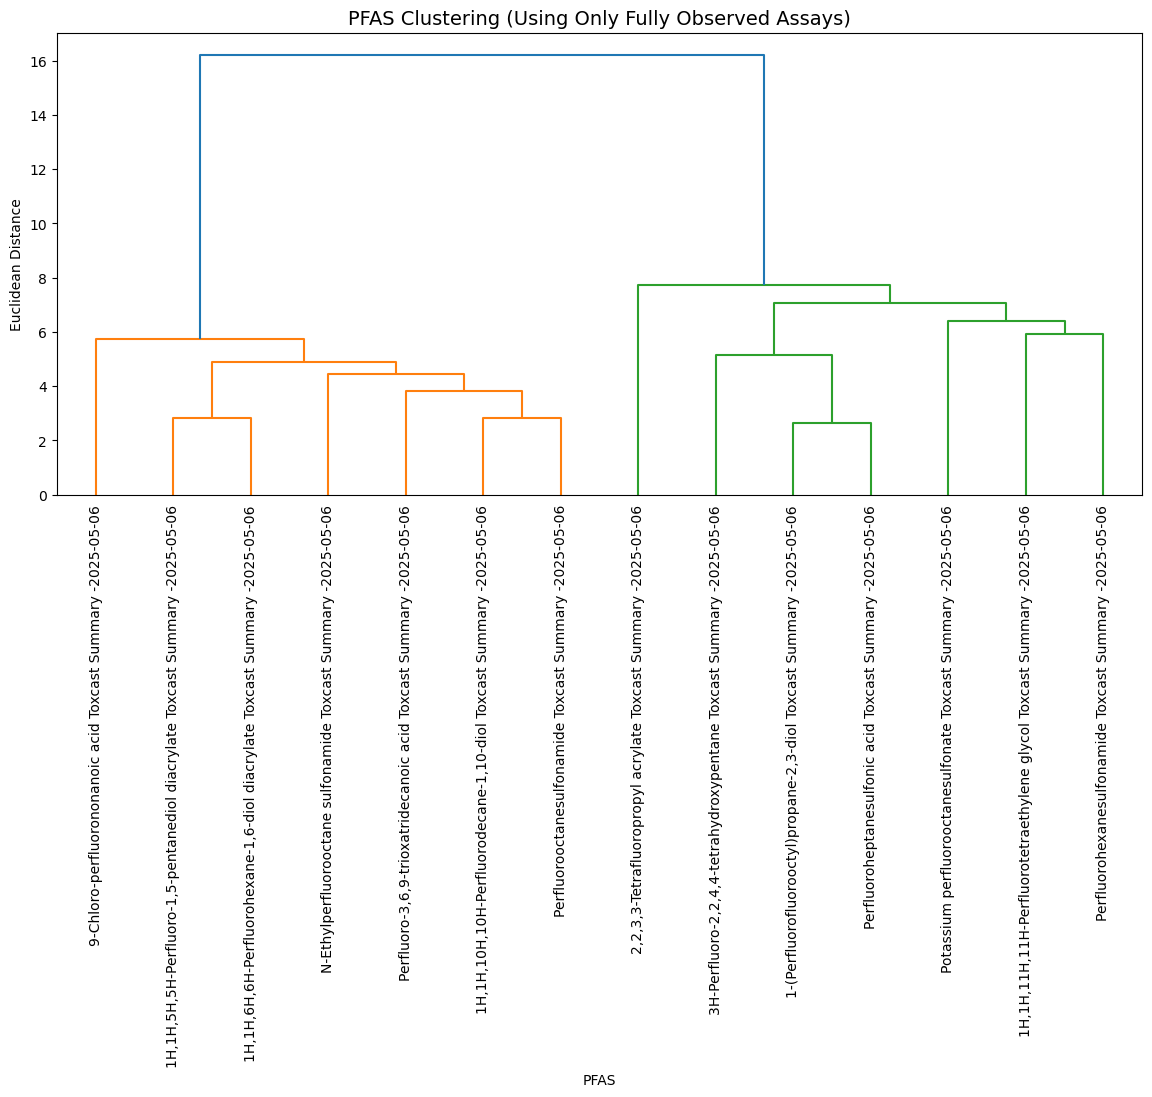

In [6]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# 1. PFAS HitCall 행렬 불러오기
file_path = r"C:\Users\exm499\Downloads\PFAS_classification\PFAS_HitCall_Matrix_Corrected.xlsx"
df = pd.read_excel(file_path, index_col=0)

# 2. 문자열을 바이너리 값으로 변환
# 'Active' → 1, 'Inactive' → 0, 'NA' → np.nan
binary_df = df.replace({"Active": 1, "Inactive": 0, "NA": np.nan}).astype(float)

# 3. NA가 전혀 없는 assay만 선택
fully_observed_assays = binary_df.columns[binary_df.notna().all()]
filtered_df = binary_df[fully_observed_assays]

print(f"✅ 사용할 수 있는 완전한 assay 수: {len(fully_observed_assays)}개")

# 4. Euclidean 거리 계산 및 Ward linkage 클러스터링
distance_matrix = pdist(filtered_df, metric='euclidean')
linked = linkage(distance_matrix, method='ward')

# 5. 덴드로그램 시각화
plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    labels=filtered_df.index,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('PFAS Clustering (Using Only Fully Observed Assays)', fontsize=14)
plt.xlabel('PFAS')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.show()

✅ 사용할 수 있는 완전한 assay 수: 95개


C:\Users\exm499\AppData\Local\Temp\ipykernel_7536\3082923443.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


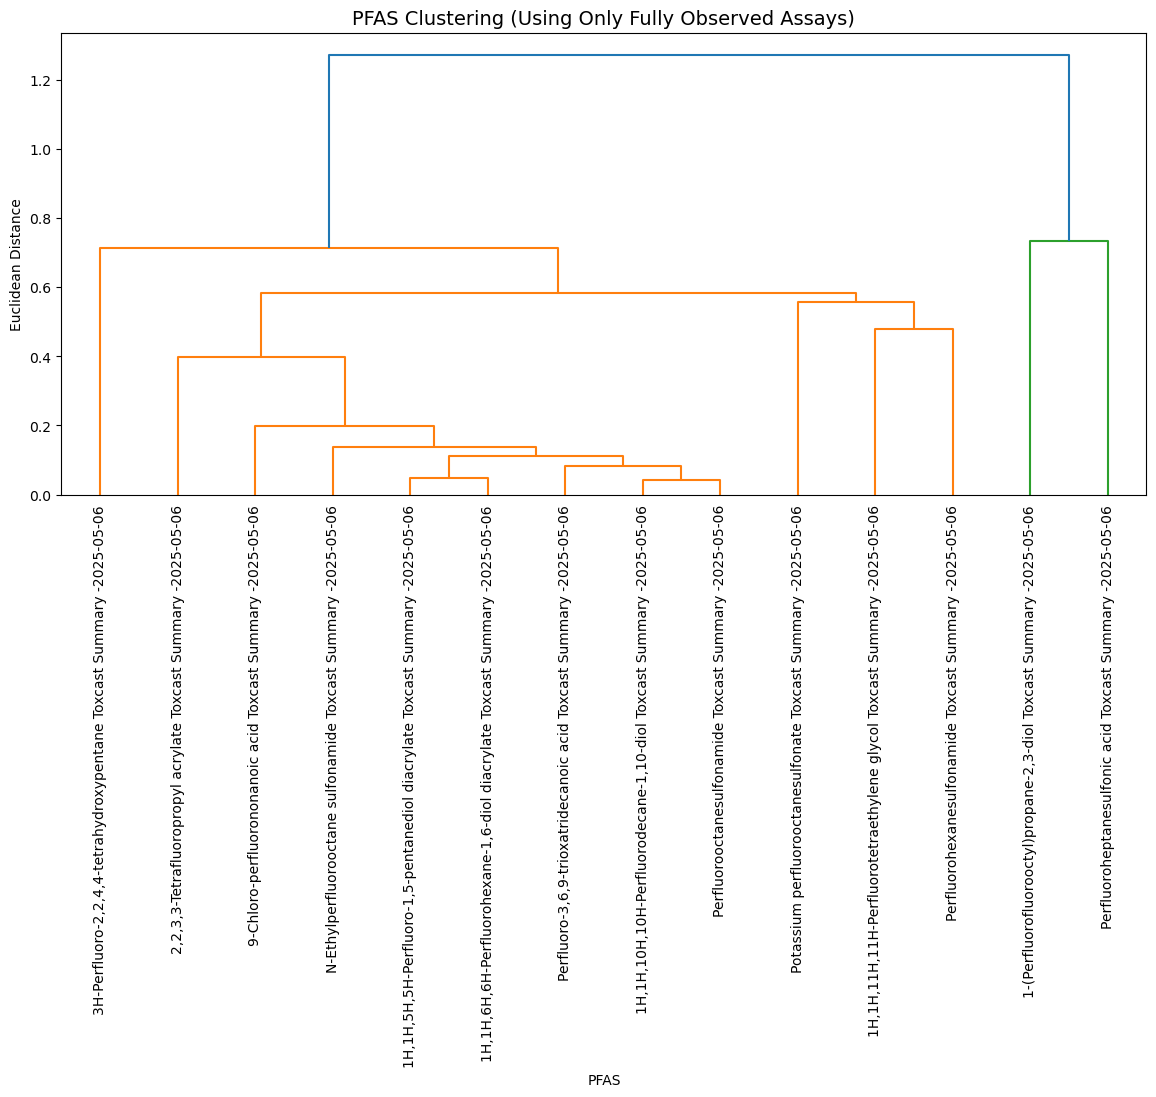

In [7]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# 1. PFAS HitCall 행렬 불러오기
file_path = r"C:\Users\exm499\Downloads\PFAS_classification\PFAS_HitCall_Matrix_Corrected.xlsx"
df = pd.read_excel(file_path, index_col=0)

# 2. 문자열을 바이너리 값으로 변환
# 'Active' → 1, 'Inactive' → 0, 'NA' → np.nan
binary_df = df.replace({"Active": 1, "Inactive": 0, "NA": np.nan}).astype(float)

# 3. NA가 전혀 없는 assay만 선택
fully_observed_assays = binary_df.columns[binary_df.notna().all()]
filtered_df = binary_df[fully_observed_assays]

print(f"✅ 사용할 수 있는 완전한 assay 수: {len(fully_observed_assays)}개")

# 4. Euclidean 거리 계산 및 Ward linkage 클러스터링
distance_matrix = pdist(filtered_df, metric='cosine')
linked = linkage(distance_matrix, method='ward')

# 5. 덴드로그램 시각화
plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    labels=filtered_df.index,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('PFAS Clustering (Using Only Fully Observed Assays)', fontsize=14)
plt.xlabel('PFAS')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.show()

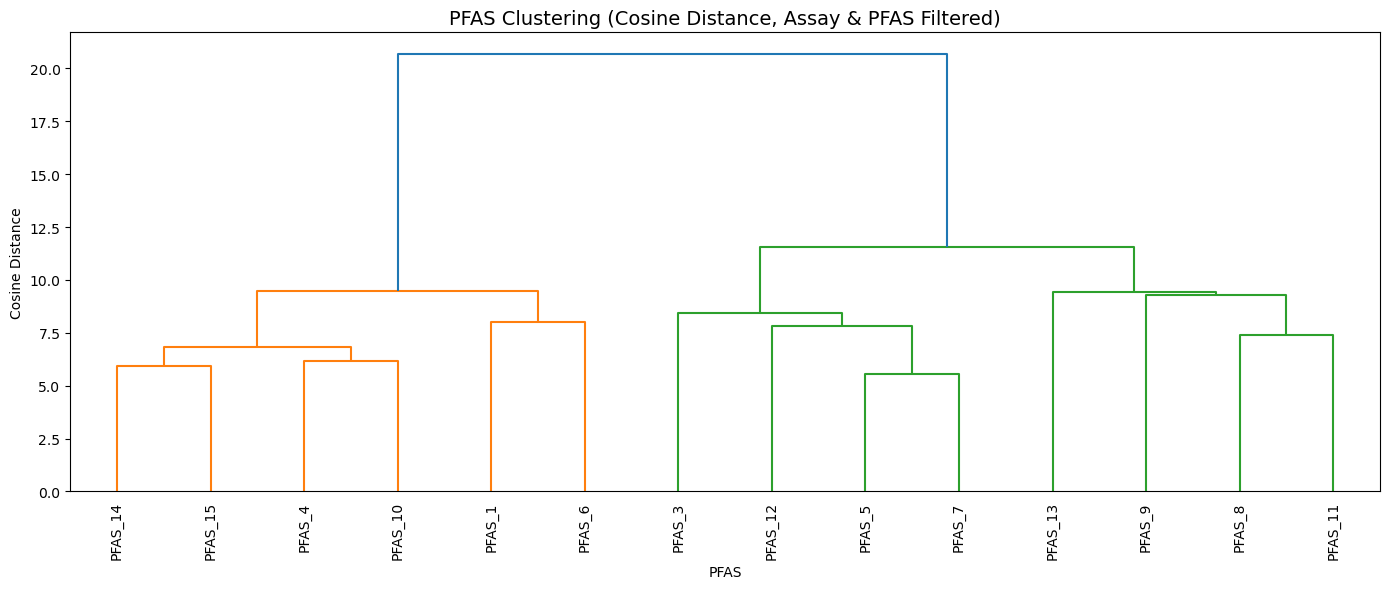

✅ 최종 포함된 PFAS 수: 14
✅ 최종 포함된 Assay 수: 233


In [1]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# 1. 데이터 로드
file_path = r"C:\Users\exm499\Downloads\PFAS_classification\PFAS_HitCall_Matrix_Corrected.xlsx"
df = pd.read_excel(file_path, index_col=0)

# 2. 문자열을 숫자형으로 변환
binary_df = df.replace({"Active": 1, "Inactive": 0, "NA": np.nan}).astype(float)

# 3. assay 필터링: 80% 이상 PFAS에서 값 존재
n_pfas = binary_df.shape[0]
assay_valid_rate = binary_df.notna().sum(axis=0) / n_pfas
selected_assays = assay_valid_rate[assay_valid_rate >= 0.8].index
filtered_df = binary_df[selected_assays]

# 4. PFAS 필터링: 80% 이상 assay가 NA인 PFAS 제거
n_assays = filtered_df.shape[1]
pfas_valid_rate = filtered_df.notna().sum(axis=1) / n_assays
filtered_df = filtered_df[pfas_valid_rate >= 0.2]

# 5. 결측값을 0으로 대체 (cosine 거리 계산을 위해)
filtered_df = filtered_df.fillna(0)

# 6. Cosine 거리 계산 및 linkage
distance_matrix = pdist(filtered_df, metric='euclidean')
linked = linkage(distance_matrix, method='ward')

# 7. 덴드로그램 시각화
plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    labels=filtered_df.index,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('PFAS Clustering (Cosine Distance, Assay & PFAS Filtered)', fontsize=14)
plt.xlabel('PFAS')
plt.ylabel('Cosine Distance')
plt.tight_layout()
plt.show()

# 8. 출력 정보
print(f"✅ 최종 포함된 PFAS 수: {filtered_df.shape[0]}")
print(f"✅ 최종 포함된 Assay 수: {filtered_df.shape[1]}")


C:\Users\exm499\AppData\Local\Temp\ipykernel_7536\930515437.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


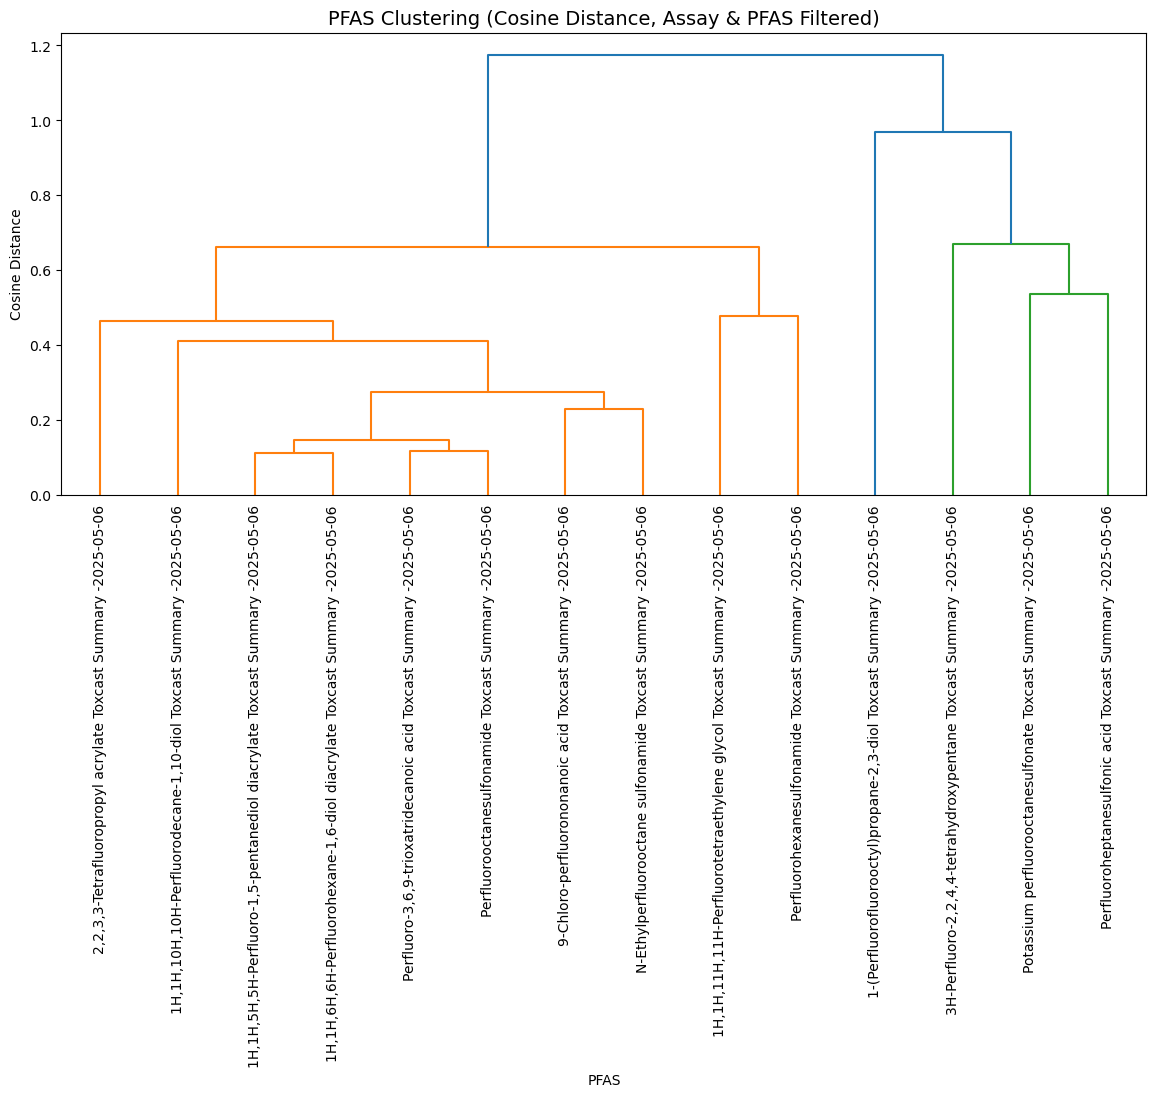

✅ 최종 포함된 PFAS 수: 14
✅ 최종 포함된 Assay 수: 233


In [23]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# 1. 데이터 로드
file_path = r"C:\Users\exm499\Downloads\PFAS_classification\PFAS_HitCall_Matrix_Corrected.xlsx"
df = pd.read_excel(file_path, index_col=0)

# 2. 문자열을 숫자형으로 변환
binary_df = df.replace({"Active": 1, "Inactive": 0, "NA": np.nan}).astype(float)

# 3. assay 필터링: 80% 이상 PFAS에서 값 존재
n_pfas = binary_df.shape[0]
assay_valid_rate = binary_df.notna().sum(axis=0) / n_pfas
selected_assays = assay_valid_rate[assay_valid_rate >= 0.8].index
filtered_df = binary_df[selected_assays]

# 4. PFAS 필터링: 80% 이상 assay가 NA인 PFAS 제거
n_assays = filtered_df.shape[1]
pfas_valid_rate = filtered_df.notna().sum(axis=1) / n_assays
filtered_df = filtered_df[pfas_valid_rate >= 0.2]

# 5. 결측값을 0으로 대체 (cosine 거리 계산을 위해)
filtered_df = filtered_df.fillna(0)

# 6. Cosine 거리 계산 및 linkage
distance_matrix = pdist(filtered_df, metric='cosine')
linked = linkage(distance_matrix, method='ward')

# 7. 덴드로그램 시각화
plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    labels=filtered_df.index,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('PFAS Clustering (Cosine Distance, Assay & PFAS Filtered)', fontsize=14)
plt.xlabel('PFAS')
plt.ylabel('Cosine Distance')
plt.tight_layout()
plt.show()

# 8. 출력 정보
print(f"✅ 최종 포함된 PFAS 수: {filtered_df.shape[0]}")
print(f"✅ 최종 포함된 Assay 수: {filtered_df.shape[1]}")
